# "Regression and Other Stories", Chapter 11 Exercises

In [1]:
import arviz
import bambi
import numpy
import pandas

from matplotlib import pyplot
from scipy import stats

/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
_BASE_SEED = """Chapter 11 -- that's the bankruptcy one.  All I can think of.  
    Even when we're on Chapter 13 I won't be thinking bankruptcy the way i am
    right now, here in Chapter 11"""

def fresh_prng(seed: str):
    return numpy.random.default_rng(seed=abs(hash(_BASE_SEED + seed)) % (2 ** 32))

## 11.3, Coverage of confidence intervals

> Consider the following procedure:
>
> *  Set $n = 100$ and draw $n$ continuous values $x_i$ uniformly distributed
>    between 0 and 10. Then simulate data from the model
>    $y_i = a + bx_i + \text{error}_i$, for $i = 1, \ldots, n$, with $a = 2$,
>    $b = 3$, and independent errors from a normal distribution.
>    
> *  Regress $y$ on $x$. Look at the median and mad sd of $b$. Check to see if
>    the interval formed by the median $\pm 2$ mad sd includes the true value,
>    $b = 3$.
>
> *  Repeat the above two steps 1000 times.
>
> (a) True or false: the interval should contain the true value approximately
>     950 times. Explain your answer.
>
> (b) Same as above, except the error distribution is bimodal, not normal. True
>     or false: the interval should contain the true value approximately 950
>     times. Explain your answer.

In [3]:
rng = fresh_prng("Exercise 11.3, Coverage of confidence intervals")

In [4]:
def regression_11_3(bimodal_noise: bool) -> bool:
    n = 100
    xs = rng.uniform(low=0, high=10, size=n)
    if bimodal_noise:
        zs = rng.choice([-1, 1], size=n)
        noise = rng.normal(loc=zs)
    else:
        noise = rng.normal(scale=1.4, size=n)
    ys = 2 + 3 * xs + noise
    model = stats.linregress(xs, ys)
    return abs(model.slope - 3) < (2 * model.stderr)

normal_count = 0
bimode_count = 0
for _ in range(1000):
    if regression_11_3(False):
        normal_count += 1
    if regression_11_3(True):
        bimode_count += 1
print(f'Normal noise: {normal_count} / 1000')
print(f'Bimodal noise: {bimode_count} / 1000')

Normal noise: 957 / 1000
Bimodal noise: 960 / 1000


## 11.4, Interpreting residual plots

> Anna takes continuous data $x_1$ and binary data $x_2$, creates fake data
> $y$ from the model, $y = a + b_1x_1 + b_2x_2 + b_3x_1x_2 + \text{error}$, and
> gives these data to Barb, who, not knowing how the data were constructed, fits
> a linear regression predicting $y$ from $x_1$ and $x_2$ but without the
> interaction. In these data, Barb makes a residual plot of $y$ vs. $x_1$, using
> dots and circles to display points with $x_2 = 0$ and $x_2 = 1$, respectively.
> The residual plot indicates to Barb that she should fit the interaction model.
> Sketch with pen on paper a residual plot that Barb could have seen after
> fitting the regression without interaction.

In [5]:
rng = fresh_prng("Exercise 11.4, Interpreting residual plots")

In [6]:
x1s = rng.normal(scale=3, size=40)
x2s = rng.choice(2, size=40)
a = 1
b1 = -2
b2 = 3
b3 = -4
ys = rng.normal(loc=(a + b1 * x1s + b2 * x2s + b3 * x1s * x2s))

In [7]:
ex4_df = pandas.DataFrame(data={'x1': x1s, 'x2': x2s, 'y': ys})

In [8]:
model_linear = bambi.Model('y ~ x1 + x2', ex4_df)
fit_linear = model_linear.fit()
summ_linear = arviz.summary(fit_linear)
a_hat = summ_linear['mean']['Intercept']
b1_hat = summ_linear['mean']['x1']
b2_hat = summ_linear['mean']['x2']
arviz.summary(fit_linear)

Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/venv/ros/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x1, x2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,5.243,0.626,4.164,6.441,0.010,0.010,4203.0,3226.0,1.0
Intercept,3.837,1.425,1.139,6.462,0.019,0.022,5899.0,3398.0,1.0
x1,-4.778,0.294,-5.317,-4.201,0.004,0.005,5207.0,3159.0,1.0
x2,-0.471,1.728,-3.677,2.835,0.021,0.027,6775.0,3393.0,1.0


In [9]:
rs = ys - (a_hat + b1_hat * x1s + b2_hat * x2s)

Text(0, 0.5, 'Residual')

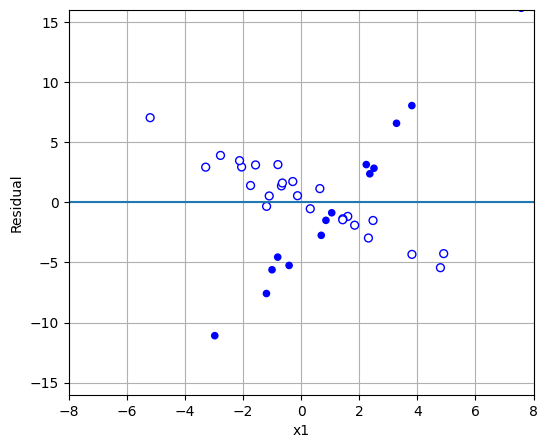

In [10]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.scatter(
    x1s,
    rs,
    s=[32 if x2i == 1 else 20 for x2i in x2s],
    c=['w' if x2i == 1 else 'b' for x2i in x2s],
    edgecolors='b',
)
ax.grid()
ax.set_xlim(-8, 8)
ax.set_ylim(-16, 16)
ax.axhline(y=0)
ax.set_axisbelow(True)
ax.set_xlabel("x1")
ax.set_ylabel("Residual")

## 11.5, Residuals and predictions

> The folder `Pyth` contains outcome $y$ and predictors $x_1, x_2$ for 40 data
> points, with a further 20 points with the predictors but no observed outcome.
> Save the file to your working directory, then read it into R using
> `read.table()`.
>
> (a) Use R to fit a linear regression model predicting $y$ from $x_1, x_2$,
>     using the first 40 data points in the file. Summarize the inferences and
>     check the fit of your model.
>
> (b) Display the estimated model graphically as in Figure 11.2.
>
> (c) Make a residual plot for this model. Do the assumptions appear to be met?
>
> (d) Make predictions for the remaining 20 data points in the file. How
>     confident do you feel about these predictions?
>
> After doing this exercise, take a look at Gelman and Nolan (2017, section
> 10.4) to see where these data came from.

In [11]:
with open('/home/bgawalt/ros/datasets/pyth.txt') as infile:
    pyth_lines = infile.readlines()

ys = []
x1s = []
x2s = []
x1news = []
x2news = []
for line in pyth_lines[1:]:
    spline = line.split()
    assert(len(spline) == 3)
    if spline[0] == "NA":
        x1news.append(float(spline[1]))
        x2news.append(float(spline[2]))
    else:
        ys.append(float(spline[0]))
        x1s.append(float(spline[1]))
        x2s.append(float(spline[2]))
print(len(ys))

40


In [12]:
pyth_df = pandas.DataFrame(data={'y': ys, 'x1': x1s, 'x2': x2s})
pyth_df.describe()

,y,x1,x2
count,40.000000,40.000000,40.000000
mean,13.590250,5.377500,11.781500
std,5.279126,3.153414,5.946086
min,3.290000,0.260000,0.720000
25%,9.325000,2.842500,6.652500
50%,15.590000,5.690000,13.245000
75%,18.002500,8.042500,17.387500
max,21.630000,9.810000,19.680000


In [13]:
model_pyth = bambi.Model('y ~ x1 + x2', pyth_df)
fit_pyth = model_pyth.fit()
summ_pyth = arviz.summary(fit_pyth)
a_hat = summ_pyth['mean']['Intercept']
b1_hat = summ_pyth['mean']['x1']
b2_hat = summ_pyth['mean']['x2']
arviz.summary(fit_pyth)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x1, x2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.935,0.116,0.722,1.146,0.002,0.002,4070.0,3204.0,1.0
Intercept,1.312,0.416,0.514,2.070,0.005,0.006,6003.0,3239.0,1.0
x1,0.515,0.048,0.422,0.605,0.001,0.001,5528.0,3483.0,1.0
x2,0.807,0.026,0.759,0.855,0.000,0.000,5960.0,3326.0,1.0


1.312 0.515 0.807


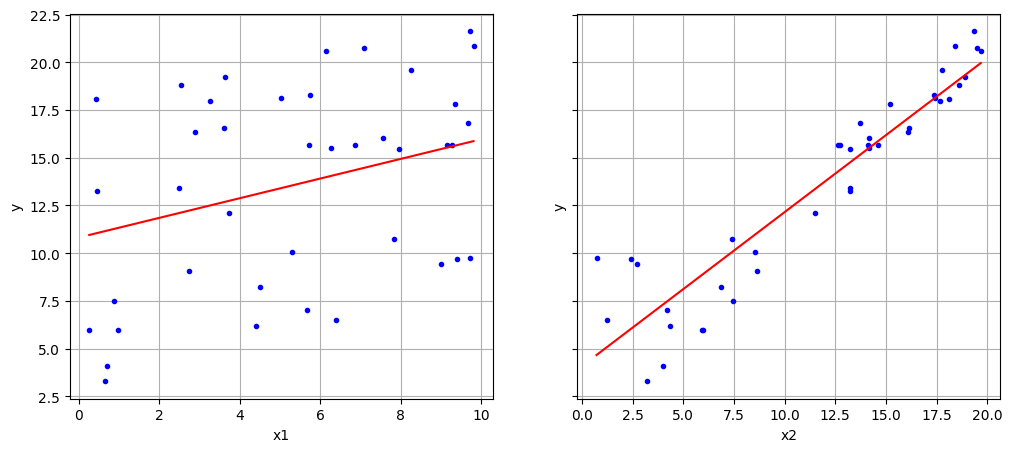

In [14]:
fig, axs = pyplot.subplots(nrows=1, ncols=2, sharex=False, sharey=True, figsize=(12,5))
print(a_hat, b1_hat, b2_hat)
axs[0].plot(x1s, ys, 'b.')
axs[0].plot(
    [min(x1s), max(x1s)],
    [
        a_hat + b1_hat * min(x1s) + b2_hat * numpy.mean(x2s),
        a_hat + b1_hat * max(x1s) + b2_hat * numpy.mean(x2s),
    ],
    'r-',
)
axs[0].set_xlabel('x1')
axs[0].set_ylabel('y')
axs[0].grid()
axs[0].set_axisbelow(True)

axs[1].plot(x2s, ys, 'b.')
axs[1].plot(
    [min(x2s), max(x2s)],
    [
        a_hat + b2_hat * min(x2s) + b1_hat * numpy.mean(x1s),
        a_hat + b2_hat * max(x2s) + b1_hat * numpy.mean(x1s),
    ],
    'r-',
)
axs[1].set_xlabel('x2')
axs[1].set_ylabel('y')
axs[1].grid()
axs[1].set_axisbelow(True)

In [15]:
yhats = []
for x1, x2 in zip(x1s, x2s):
    yhats.append(a_hat + b1_hat * x1 + b2_hat * x2)
resids = [yi - yhat_i for (yi, yhat_i) in zip(ys, yhats)]

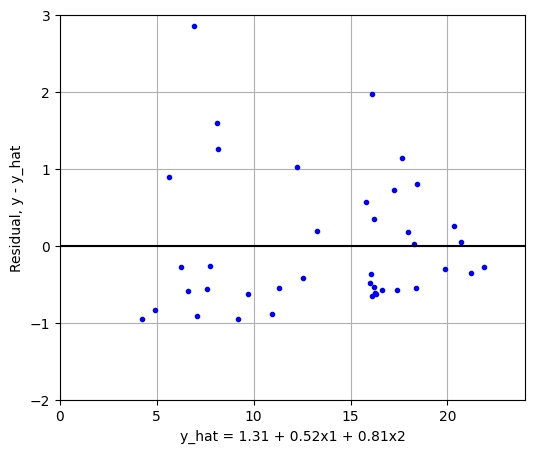

In [16]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(yhats, resids, 'b.')
ax.set_xlabel(f'y_hat = {a_hat:0.2f} + {b1_hat:0.2f}x1 + {b2_hat:0.2f}x2')
ax.set_ylabel('Residual, y - y_hat')
ax.grid()
ax.axhline(y=0, color='k')
ax.set_ylim(-2, 3)
ax.set_xlim(0, 24)
ax.set_axisbelow(True)

In [17]:
print('$x_1$   | $x_2$   | $\hat{y}$')
print('------- | ------- | ---------')
ynews = []
for x1, x2 in zip(x1news, x2news):
    yhat = a_hat + x1 * b1_hat + x2 * b2_hat
    ynews.append(yhat)
    print(f'{x1:0.2f}    | {x2:0.2f}   | {yhat:0.2f}')

$x_1$   | $x_2$   | $\hat{y}$
------- | ------- | ---------
9.87    | 10.43   | 14.81
9.99    | 15.72   | 19.14
8.39    | 0.35   | 5.92
0.80    | 10.91   | 10.53
9.58    | 15.82   | 19.01
4.82    | 11.90   | 13.40
2.97    | 2.46   | 4.83
8.80    | 4.09   | 9.14
6.07    | 1.80   | 5.89
0.19    | 13.54   | 12.34
4.19    | 19.13   | 18.91
5.39    | 14.84   | 16.06
6.58    | 5.28   | 8.96
2.36    | 15.42   | 14.97
2.37    | 4.12   | 5.86
1.52    | 6.54   | 7.37
2.07    | 2.67   | 4.53
6.70    | 12.85   | 15.13
2.02    | 8.36   | 9.10
9.63    | 12.16   | 16.08


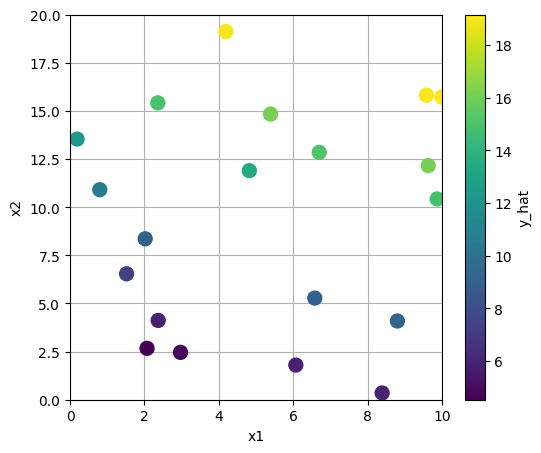

In [18]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
sc = ax.scatter(x1news, x2news, c=ynews, cmap='viridis', s=100)
ax.grid()
ax.set_axisbelow(True)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('y_hat')

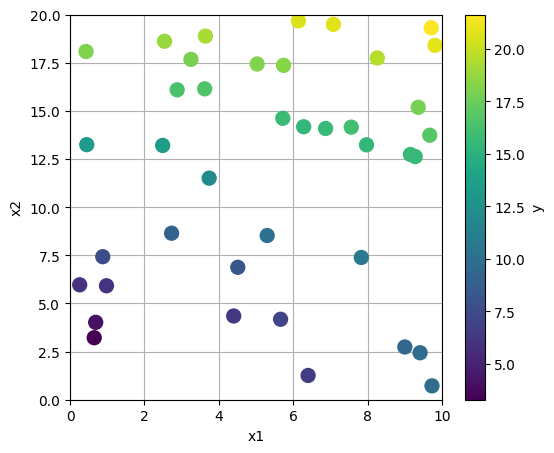

In [19]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
sc = ax.scatter(x1s, x2s, c=ys, cmap='viridis', s=100)
ax.grid()
ax.set_axisbelow(True)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('y')

(Moved this to the end so it doesn't run so often, or so that if it does run, I can kill it.)

## 11.6, Fitting a wrong model

> Suppose you have 100 data points that arose from the following model:
> $y = 3 + 0.1 x_1 + 0.5 x_2 + \text{error}$, with independent errors drawn from
> a $t$ distribution with mean 0, scale 5, and 4 degrees of freedom. We shall
> explore the implications of fitting a standard linear regression to these
> data.
>
> (a) Simulate data from this model. For simplicity, suppose the values of $x_1$
>     are simply the integers from 1 to 100, and that the values of $x_2$ are
>     random and equally likely to be 0 or 1. In R, you can define
>     `x_1 <- 1:100`, simulate `x_2` using `rbinom`, then create the linear
>     predictor, and finally simulate the random errors in `y` using the `rt`
>     function. Fit a linear regression (with normal errors) to these data and
>     see if the 68% confidence intervals for the regression coefficients (for
>     each, the estimates $\pm 1$ standard error) cover the true values.
>
> (b) Put the above step in a loop and repeat 1000 times. Calculate the
>     confidence coverage for the 68% intervals for each of the three
>     coefficients in the model.


In [30]:
rng = fresh_prng("Exercise 11.6, Fitting a wrong model")

In [31]:
x1s = numpy.arange(1, 101)

In [32]:
def wrong_coverage() -> (float, float):
    """Returns (actual - mean)/s.e. for b1 and b2."""
    x2s = rng.choice(2, size=100)
    ys = 3 + 0.1 * x1s + 0.5 * x2s + stats.t.rvs(df=4, scale=5, size=100)
    wrong_df = pandas.DataFrame(data={'y': ys, 'x1': x1s, 'x2': x2s})
    model = bambi.Model('y ~ x1 + x2', wrong_df)
    fit = model.fit()
    summ = arviz.summary(fit)
    a_hat = summ['mean']['Intercept']
    b1_hat = summ['mean']['x1']
    b2_hat = summ['mean']['x2']
    return ((0.1 - b1_hat) / summ['sd']['x1'], (0.5 - b2_hat) / summ['sd']['x2'])

In [40]:
num_sims = 1  # Should be 100 or 1000, but I don't want to accidentally rerun this that many times.
z1s = []
z2s = []
for _ in range(num_sims):
    z1, z2 = wrong_coverage()
    z1s.append(z1)
    z2s.append(z2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x1, x2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Text(0, 0.5, 'Count')

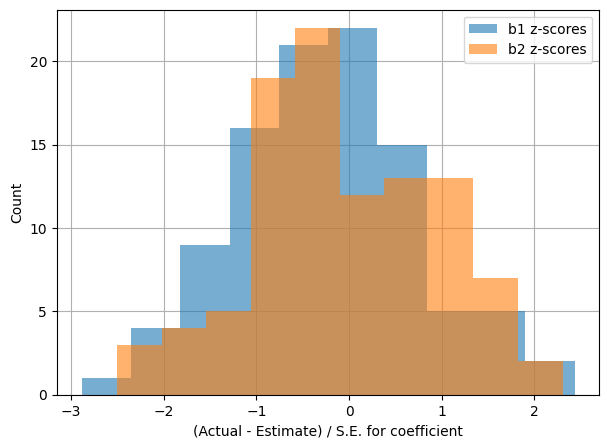

In [39]:
fig = pyplot.figure(figsize=(7,5))
ax = fig.gca()
ax.hist(z1s, alpha=0.6, label="b1 z-scores")
ax.hist(z2s, alpha=0.6, label="b2 z-scores")
ax.grid()
ax.legend()
ax.set_axisbelow(True)
ax.set_xlabel('(Actual - Estimate) / S.E. for coefficient')
ax.set_ylabel('Count')

In [38]:
print(f"b1's within one s.e.: {sum(1 if abs(zi) < 1 else 0 for zi in z1s)}")
print(f"b2's within one s.e.: {sum(1 if abs(zi) < 1 else 0 for zi in z2s)}")

b1's within one s.e.: 66
b2's within one s.e.: 70
